# IAT 360 - Group 6 Sarcasm Detector (BERT/Hugging Face/PyTorch)

**Group notes:**
1. Set runtime to GPU T4 on top right so we don't accidentally start a fusion reaction out of our CPU
2. Double check that 'TRAIN_PATH' and 'TEST_PATH' follow the correct paths
3. There's almost a **MILLION** rows in the training set and it'll likely take over an hour to train, set 'TRAIN_SUBSET' to something like 5000 instead to test if it works. The best model will be uploaded to the Drive each epoch so don't worry about disconnects

##Project Description

Caustic and humorous wordplay is a linguistic phenomena that would likely fall flat to an untrained AI. We’d like to try and train an NLP model to classify whether a social media comment is sarcastic or not, which may help avoid any miscommunications between an AI misinterpreting an ironic statement as literal. This could be useful for training virtual assistant chatbots to detect client emotions, and help break the ice of a person’s views towards virtual assistants.

##Model

We'll be transfer training Google's Bidirectional Encoder Representations from Transformers (BERT) model. We found it useful for the fact that it was already pre-trained by Google on the English language so that we may train it to detect sarcasm. One issue is that the old notebook, among several issues like swapped paths (training on the test set, and testing on the giant training set) and manually importing zip files of BERT weights, also used a library we couldn't use in Colab. We had to instead import it from Hugging Face, which no longer supported TensorFlow in favour of PyTorch.

Dataset - https://www.kaggle.com/datasets/wenxindong/sarcasm
Old Code - https://www.kaggle.com/code/wenxindong/binary-model

In [3]:
!pip install -q -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 50.1 MB/s eta 0:00:00


In [4]:
import torch, transformers
print("torch", torch.__version__)
print("transformers", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

torch 2.11.0+cu128
transformers 5.14.1
CUDA available: True


In [5]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("WARNING: no GPU detected. Switch the runtime to GPU before training.")

Using device: cuda


In [6]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

## Load the data from Drive

`TRAIN_SUBSET` lets you train on a random assortment of however much you want while you're testing the pipeline set it back to `None` for the whole thing (don't)

In [9]:
TRAIN_PATH = "/content/drive/MyDrive/NLP_Final/Datasets/sarcastic_binary_train.csv"
TEST_PATH  = "/content/drive/MyDrive/NLP_Final/Datasets/sarcastic_binary_test.csv"
SAVE_DIR   = "/content/drive/MyDrive/NLP_Final/Ju_Checkpoint/best_model"
TRAIN_SUBSET = 100000 # Training set size hyperparameter, Make sure TRAIN_SUBSET is None if you want to train the entire dataset

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
print("raw:", train_df.shape, test_df.shape)

raw: (1008773, 3) (2000, 2)


prepared: (100000, 3) (1988, 3)
label
1    0.50341
0    0.49659


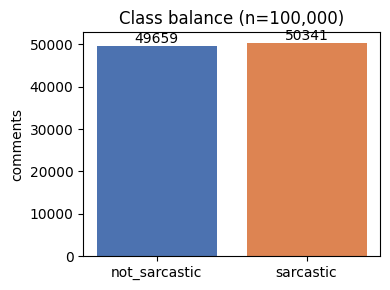

In [10]:
import matplotlib.pyplot as plt

def clean(text):
    text = re.sub(r"https?://\S+|www\.\S+", "", str(text))
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def prepare(df):
    df = df.drop_duplicates()
    if "sample_weight" not in df.columns:
        df = df.assign(sample_weight=1.0)
    df = df[["text", "label", "sample_weight"]].dropna(subset=["text", "label"])
    df = df.assign(text=df["text"].map(clean))
    df = df[df["text"].str.len() > 0].reset_index(drop=True)
    return df

train_df = prepare(train_df)
test_df  = prepare(test_df)

if TRAIN_SUBSET is not None: #Pick (TRAIN_SUBSET) amount of rows to sample from, the rows are randomly picked. Since the full dataset is balanced, on average, so will the subset
    train_df = train_df.sample(TRAIN_SUBSET, random_state=42).reset_index(drop=True)

print("prepared:", train_df.shape, test_df.shape)
print(train_df["label"].value_counts(normalize=True).to_string())

counts = train_df["label"].value_counts().sort_index()
labels = ["not_sarcastic","sarcastic"]
#Double check class balance, expect each label to be close to exactly (TRAIN_SUBSET)/2
plt.figure(figsize=(4,3))
bars = plt.bar(labels, counts, color=["#4C72B0","#DD8452"])
plt.bar_label(bars)
plt.title(f"Class balance (n={len(train_df):,})")
plt.ylabel("comments")
plt.tight_layout()
plt.show()

## Tokenize

`bert-base-uncased` lowercases internally, so we don't lowercase here. Comments longer than `MAX_LEN`are truncated since this dataset is already enormous enough to handle without the need to trim it significantly

In [11]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128 #Batch Size Hyperparameter
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode(texts):
    return tokenizer(list(texts), truncation=True, max_length=MAX_LEN)

train_enc = encode(train_df["text"])
test_enc  = encode(test_df["text"])
#ignore the warnings, download works anonymously, just slower

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [12]:
class SarcasmDataset(Dataset):
    def __init__(self, enc, labels, weights):
        self.input_ids = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels = list(labels)
        self.weights = list(weights)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids": self.input_ids[i],
            "attention_mask": self.attention_mask[i],
            "label": self.labels[i],
            "weight": self.weights[i],
        }

def collate(batch):
    padded = tokenizer.pad(
        {"input_ids": [b["input_ids"] for b in batch],
         "attention_mask": [b["attention_mask"] for b in batch]},
        return_tensors="pt",
    )
    padded["labels"] = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    padded["weights"] = torch.tensor([b["weight"] for b in batch], dtype=torch.float)
    return padded

train_ds = SarcasmDataset(train_enc, train_df["label"], train_df["sample_weight"])
test_ds  = SarcasmDataset(test_enc, test_df["label"], test_df["sample_weight"])

BATCH_SIZE = 16 #Batch Size Hyperparam
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate)

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

EPOCHS = 3 #Epochs Size, try not to push more than 4 epochs due to overfitting issues
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5) #Learning Rate Hyperparam (0.00002)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
loss_fn = nn.CrossEntropyLoss(reduction="none")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds, gold = [], []
    total_loss, total_n = 0.0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = torch.nn.functional.cross_entropy(logits.float(), labels)
        total_loss += loss.item() * labels.size(0)
        total_n += labels.size(0)
        preds.extend(logits.argmax(-1).cpu().tolist())
        gold.extend(labels.cpu().tolist())
    return {
        "loss": total_loss / total_n,
        "acc": accuracy_score(gold, preds),
        "f1": f1_score(gold, preds),
        "precision": precision_score(gold, preds),
        "recall": recall_score(gold, preds),
    }

##Trainer

In [1]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

best_f1 = 0.0
history = []

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for batch in tqdm(train_loader, desc=f"epoch {epoch+1}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        weights = batch["weights"].to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            losses = loss_fn(logits, labels)
            loss = (losses * weights).mean()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running += loss.item()

    val = evaluate(test_loader)
    print(f"epoch {epoch+1}  train_loss={running/len(train_loader):.4f}  "
          f"eval_loss={val['loss']:.4f}  acc={val['acc']:.4f}  f1={val['f1']:.4f}")
    history.append({
        "epoch": epoch + 1,
        "train_loss": running / len(train_loader),
        "val_loss": val["loss"],
        "val_acc": val["acc"],
        "val_f1": val["f1"],
        "val_precision": val["precision"],
        "val_recall": val["recall"],
    })
    if val["f1"] > best_f1:
        best_f1 = val["f1"]
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print("  saved new best ->", SAVE_DIR)

NameError: name 'EPOCHS' is not defined

In [ ]:
final = evaluate(test_loader)
print(f"Final  accuracy={final['acc']:.4f}  f1={final['f1']:.4f}")

model.eval()
preds, gold = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds.extend(logits.argmax(-1).cpu().tolist())
        gold.extend(batch["labels"].tolist())
print(classification_report(gold, preds, target_names=["not_sarcastic", "sarcastic"]))

##Results

In [2]:
import os, json, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

RUN_NAME = "bert_100000dataset" #Rename this to whatever your test will be
LR = 2e-5
RESULTS_ROOT = "/content/drive/MyDrive/NLP_Final/Results"

def next_run_dir(root, name):
    os.makedirs(root, exist_ok=True)
    idxs = [int(d[len(name)+1:]) for d in os.listdir(root)
            if d.startswith(name + "_") and d[len(name)+1:].isdigit()]
    idx = max(idxs) + 1 if idxs else 1
    path = os.path.join(root, f"{name}_{idx}")
    os.makedirs(path, exist_ok=True)
    return path, idx

run_dir, run_idx = next_run_dir(RESULTS_ROOT, RUN_NAME)

@torch.no_grad()
def predict(df, loader):
    model.eval()
    preds, probs = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        p = torch.softmax(logits.float(), dim=-1)
        preds.extend(p.argmax(-1).cpu().tolist())
        probs.extend(p[:, 1].cpu().tolist())
    out = df.copy()
    out["predicted"] = preds
    out["prob_sarcastic"] = probs
    out["correct"] = (out["predicted"] == out["label"]).astype(int)
    return out

pred_df = predict(test_df, test_loader)
pred_df.to_csv(os.path.join(run_dir, "test_predictions.csv"), index=False)

errors = pred_df[pred_df["correct"] == 0].copy()
errors["confidence"] = np.where(errors["predicted"] == 1,
                                errors["prob_sarcastic"], 1 - errors["prob_sarcastic"])
errors.sort_values("confidence", ascending=False).to_csv(
    os.path.join(run_dir, "confident_mistakes.csv"), index=False)

gold, preds = pred_df["label"].tolist(), pred_df["predicted"].tolist()
metrics = {
    "run_name": RUN_NAME, "run_index": run_idx,
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    "accuracy": float(accuracy_score(gold, preds)),
    "f1_sarcastic": float(f1_score(gold, preds)),
    "f1_macro": float(f1_score(gold, preds, average="macro")),
    "precision": float(precision_score(gold, preds)),
    "recall": float(recall_score(gold, preds)),
    "best_val_f1": float(max(e["val_f1"] for e in history)),
    "model_name": MODEL_NAME, "learning_rate": LR, "epochs": EPOCHS,
    "batch_size": BATCH_SIZE, "max_len": MAX_LEN,
    "n_train": int(len(train_df)), "n_test": int(len(test_df)),
    "train_subset": TRAIN_SUBSET,
    "torch": torch.__version__, "transformers": transformers.__version__,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
}
with open(os.path.join(run_dir, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

with open(os.path.join(run_dir, "classification_report.txt"), "w") as f:
    f.write(classification_report(gold, preds, target_names=["not_sarcastic", "sarcastic"]))

pd.DataFrame(history).to_csv(os.path.join(run_dir, "history.csv"), index=False)

def _smooth(y, frac=0.15):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 5:
        return y
    w = max(3, int(round(n * frac)))
    if w % 2 == 0:
        w += 1
    ypad = np.pad(y, w // 2, mode="edge")
    return np.convolve(ypad, np.ones(w) / w, mode="valid")

def plot_dashboard(history, out_path, title):
    h = pd.DataFrame(history)
    x = h["epoch"].values
    panels = [
        ("train/loss", "train_loss"),
        ("eval/loss", "val_loss"),
        ("metrics/accuracy", "val_acc"),
        ("metrics/precision", "val_precision"),
        ("metrics/recall", "val_recall"),
        ("metrics/f1", "val_f1"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, (name, key) in zip(axes.ravel(), panels):
        if key not in h.columns:
            ax.set_visible(False)
            continue
        y = h[key].values
        ax.plot(x, y, marker="o", label="results")
        if len(y) >= 5:
            ax.plot(x, _smooth(y), linestyle=":", label="smooth")
        ax.set_title(name)
        ax.set_xlabel("epoch")
        ax.set_xticks(x)
        ax.grid(alpha=0.2)
    axes.ravel()[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=120)
    plt.show()

plot_dashboard(history, os.path.join(run_dir, "results.png"), f"{RUN_NAME}_{run_idx}")

cm = confusion_matrix(gold, preds)
np.savetxt(os.path.join(run_dir, "confusion_matrix.csv"), cm, fmt="%d", delimiter=",")
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["not_sarcastic", "sarcastic"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
plt.title(f"{RUN_NAME}_{run_idx}")
plt.tight_layout()
plt.savefig(os.path.join(run_dir, "confusion_matrix.png"), dpi=120)
plt.show()

master = os.path.join(RESULTS_ROOT, "all_runs.csv") #This will add this run's results to a row on the master csv
pd.DataFrame([metrics]).to_csv(master, mode="a", header=not os.path.exists(master), index=False)
print("Saved run to:", run_dir)
print("Appended summary to:", master)

NameError: name 'torch' is not defined

## Test Best Model Here


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

SAVE_DIR = "/content/drive/MyDrive/NLP_Final/Ju_Checkpoint/best_model"  #Match the best_model path here
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tok = AutoTokenizer.from_pretrained(SAVE_DIR)
mdl = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
mdl.eval()

@torch.no_grad()
def predict(text):
    enc = tok(text, truncation=True, max_length=128, return_tensors="pt").to(device)
    probs = torch.softmax(mdl(**enc).logits, dim=-1)[0]
    label = "sarcastic" if probs[1] > probs[0] else "not_sarcastic"
    return label, probs[1].item()

label, conf = predict("Oh, well that's just great. Very good job there, idiot!")
print(f"{label}  (p_sarcastic={conf:.2f})")

In [ ]:
import os, datetime
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output

LOG_PATH = os.path.join(SAVE_DIR, "live_predictions.csv")

text_box   = widgets.Textarea(placeholder="Type a comment here...",
                              layout=widgets.Layout(width="500px", height="60px"))
predict_btn = widgets.Button(description="Predict", button_style="primary")
result_out  = widgets.Output()
feedback_box = widgets.HBox([])
status_out  = widgets.Output()

state = {}

def log_row(true_label):
    row = {
        "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
        "text": state["text"],
        "predicted": state["pred_label"],
        "prob_sarcastic": round(state["prob"], 4),
        "true_label": true_label,
        "correct": int(state["pred_label"] == true_label),
    }
    pd.DataFrame([row]).to_csv(LOG_PATH, mode="a",
                              header=not os.path.exists(LOG_PATH), index=False)

def on_feedback(correct):
    true_label = state["pred_label"] if correct else (
        "not_sarcastic" if state["pred_label"] == "sarcastic" else "sarcastic")
    log_row(true_label)
    with status_out:
        clear_output()
        n = len(pd.read_csv(LOG_PATH))
        print(f"Logged. Recorded true label: {true_label}.  Total in log: {n}")
    feedback_box.children = ()

def on_predict(_):
    text = text_box.value.strip()
    with status_out:
        clear_output()
    with result_out:
        clear_output()
        if not text:
            print("Type something first.")
            return
        label, prob = predict(text)
        state.update(text=text, pred_label=label, prob=prob)
        print(f"Prediction: {label}   (p_sarcastic={prob:.2f})")
    if not text:
        return
    correct_btn = widgets.Button(description="Correct", button_style="success")
    wrong_btn   = widgets.Button(description="Wrong", button_style="danger")
    correct_btn.on_click(lambda _: on_feedback(True))
    wrong_btn.on_click(lambda _: on_feedback(False))
    feedback_box.children = (widgets.Label("Was it right?"), correct_btn, wrong_btn)

predict_btn.on_click(on_predict)
display(widgets.VBox([text_box, predict_btn, result_out, feedback_box, status_out]))